In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import accuracy,logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt
seed=42
np.random.seed(seed)

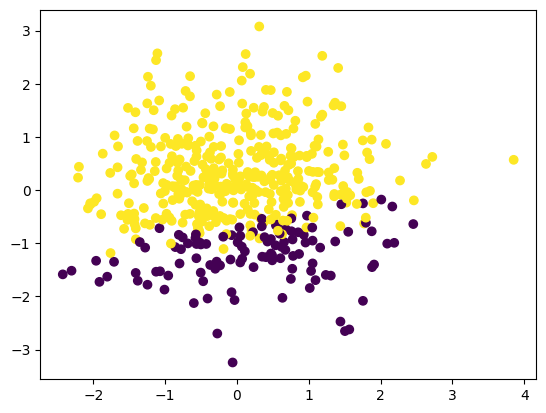

In [3]:
# Sample Code for generating datasets
size=500
seed=42
dim=2
noise_bound = 0.2
np.random.seed(seed)
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [4]:
loaded_data = np.load(f'data/logistic_data_A.npz')

# 從裡面把變數拿出來 (對應上面儲存時的名稱)
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
print(f"X size : {X.shape}, y size : {y.shape}")
size = X.shape[0]
dim = X.shape[1]-1

X size : (2000, 3), y size : (2000,)


# Customized Logistic Regression

In [5]:
from model.linear_model import LinearModel

## Gradient Descent, no L2

20. Training loss: 0.6458180458212025, Val loss:0.6356861093315146
40. Training loss: 0.6211358361455644, Val loss:0.6123253755691555
60. Training loss: 0.5985262155535839, Val loss:0.5909802908766331
80. Training loss: 0.5778081881483563, Val loss:0.5714692873794853
100. Training loss: 0.5588099299555331, Val loss:0.5536205174928406
120. Training loss: 0.5413705517223792, Val loss:0.537273633540043
140. Training loss: 0.5253411140481187, Val loss:0.5222807720538902
160. Training loss: 0.5105850275823942, Val loss:0.5085068877832022
180. Training loss: 0.4969779768619942, Val loss:0.49582959031198204
200. Training loss: 0.48440749796178545, Val loss:0.48413862675562525
220. Training loss: 0.47277232324407253, Val loss:0.4733351341831506
240. Training loss: 0.4619815858565417, Val loss:0.4633307612378982
260. Training loss: 0.4519539556974867, Val loss:0.454046734239807
280. Training loss: 0.4426167594881642, Val loss:0.4454129214585394
300. Training loss: 0.4339051214484235, Val loss:0

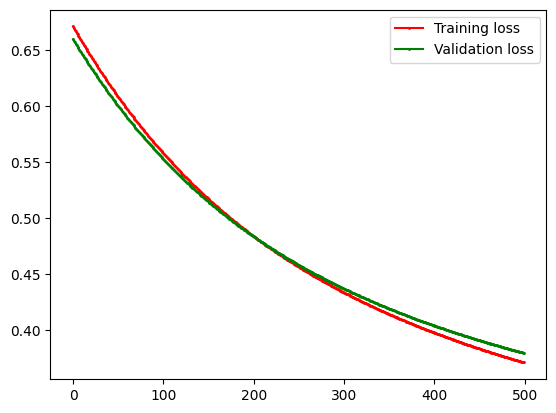

In [ ]:
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad
X_train,y_train,X_val,y_val = get_train_val(X,y)
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [11]:

y_pred = model.predict(X_val)
print(accuracy(y_val,y_pred))

0.9025


Plot validation set and decision boundary

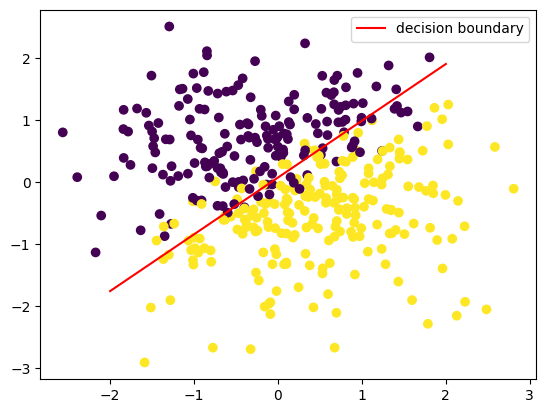

In [12]:
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()